# Día 2: clasificación de `dedo` con CNNs

## Objetivo

En este cuaderno vais a resolver la tarea `dedo` con aprendizaje profundo.

No hace falta que todo el mundo llegue a la misma arquitectura ni al mismo pipeline. La meta es montar una solución completa y razonable que parta de imágenes y termine en predicciones evaluadas sobre test.

Al terminar, deberíais tener:

- un dataset bien organizado;
- un reparto reproducible entre train, validación y test;
- `datasets` y `dataloaders` funcionales;
- al menos un modelo entrenado;
- métricas y ejemplos de errores.

## Posibles caminos

Podéis elegir uno o comparar varios:

- entrenar una CNN pequeña desde cero;
- hacer `fine-tuning` de un modelo preentrenado;
- trabajar con la imagen completa;
- trabajar con un recorte o panel rectificado;
- usar augmentations suaves o más agresivas;

## Instalación

```bash
pip install --upgrade numpy pandas matplotlib pillow opencv-python scikit-learn torch torchvision pytorch-lightning seaborn
```

## Importaciones

In [142]:

# Escribe aquí las importaciones necesarias.
import os
import random
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import medmnist
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from IPython.display import Image
from medmnist import INFO, Evaluator
from PIL import Image as PILImage
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset
from torchvision.models import mobilenet_v3_small
from tqdm import tqdm

# Esto sobreescribe la representación por defecto de los tensores para hacerla más legible
import lovely_tensors as lt
lt.monkey_patch()

## Configuración general

Piensa qué hiperparámetros quieres fijar desde el principio.

Por ejemplo:

- ruta del dataset;
- semilla aleatoria;
- tamaños de `train`, `val` y `test`;
- tamaño de imagen;
- `batch_size`;
- número de épocas;
- tasa de aprendizaje.

In [143]:
# Define aquí la configuración general del experimento.

# Semilla aleatoria para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Ruta del dataset
DATA_DIR = '/home/manel31/Escritorio/cursoIA/dedo'

# Tamaño de imagen
IMG_SIZE = 224

# Hiperparámetros de entrenamiento
BATCH_SIZE = 32
NUM_EPOCHS = 60
LEARNING_RATE = 1e-3

# Proporciones de separación
TEST_SIZE = 0.20
VAL_SIZE = 0.10

# Device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Usando dispositivo: {DEVICE}')

Usando dispositivo: cuda


## Cargar el dataset `dedo`

Construye una tabla con rutas y etiquetas. Igual que el día 1, conviene empezar por una visión clara del dataset.

In [144]:
    # Recorre aquí la carpeta data/dedo y crea un DataFrame.
    records = []
    data_path = Path(DATA_DIR)

    for class_folder in sorted(data_path.iterdir()):
        if class_folder.is_dir():
            label = class_folder.name
            for img_path in class_folder.glob('*'):
                if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                    records.append({'path': str(img_path), 'label': label})

    df = pd.DataFrame(records)

    # Codificar etiquetas como enteros
    label_to_idx = {label: idx for idx, label in enumerate(sorted(df['label'].unique()))}
    idx_to_label = {v: k for k, v in label_to_idx.items()}
    df['label_idx'] = df['label'].map(label_to_idx)

    print(f'Total de imágenes: {len(df)}')
    print(f'Clases: {label_to_idx}')
    df.head()

Total de imágenes: 81
Clases: {'no': 0, 'si': 1}


,path,label,label_idx
0,/home/manel31/Escritorio/cursoIA/dedo/no/img_1...,no,0
1,/home/manel31/Escritorio/cursoIA/dedo/no/img_1...,no,0
2,/home/manel31/Escritorio/cursoIA/dedo/no/img_1...,no,0
3,/home/manel31/Escritorio/cursoIA/dedo/no/img_1...,no,0
4,/home/manel31/Escritorio/cursoIA/dedo/no/img_1...,no,0


label
si    44
no    37
Name: count, dtype: int64


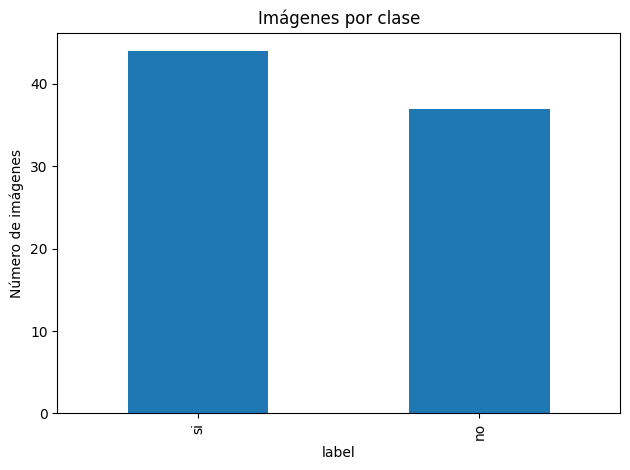

In [145]:
# Resume aquí el número de imágenes por clase.
print(df['label'].value_counts())
df['label'].value_counts().plot(kind='bar', title='Imágenes por clase')
plt.ylabel('Número de imágenes')
plt.tight_layout()
plt.show()

## Separación de datos

Reserva un conjunto de test reproducible y crea una validación interna usando solo el conjunto de entrenamiento.
Usa el mismo criterio de separación que el día 1.

In [146]:
# Crea aquí train, val y test.
# Primera separación: train+val vs test
train_val_df, test_df = train_test_split(
    df, test_size=TEST_SIZE, random_state=SEED, stratify=df['label_idx']
)

# Segunda separación: train vs val (sobre el conjunto train+val)
val_relative_size = VAL_SIZE / (1 - TEST_SIZE)
train_df, val_df = train_test_split(
    train_val_df, test_size=val_relative_size, random_state=SEED, stratify=train_val_df['label_idx']
)

# Reiniciar índices
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train: {len(train_df)} imágenes')
print(f'Val:   {len(val_df)} imágenes')
print(f'Test:  {len(test_df)} imágenes')

Train: 56 imágenes
Val:   8 imágenes
Test:  17 imágenes


## Explorar imágenes antes de entrenar

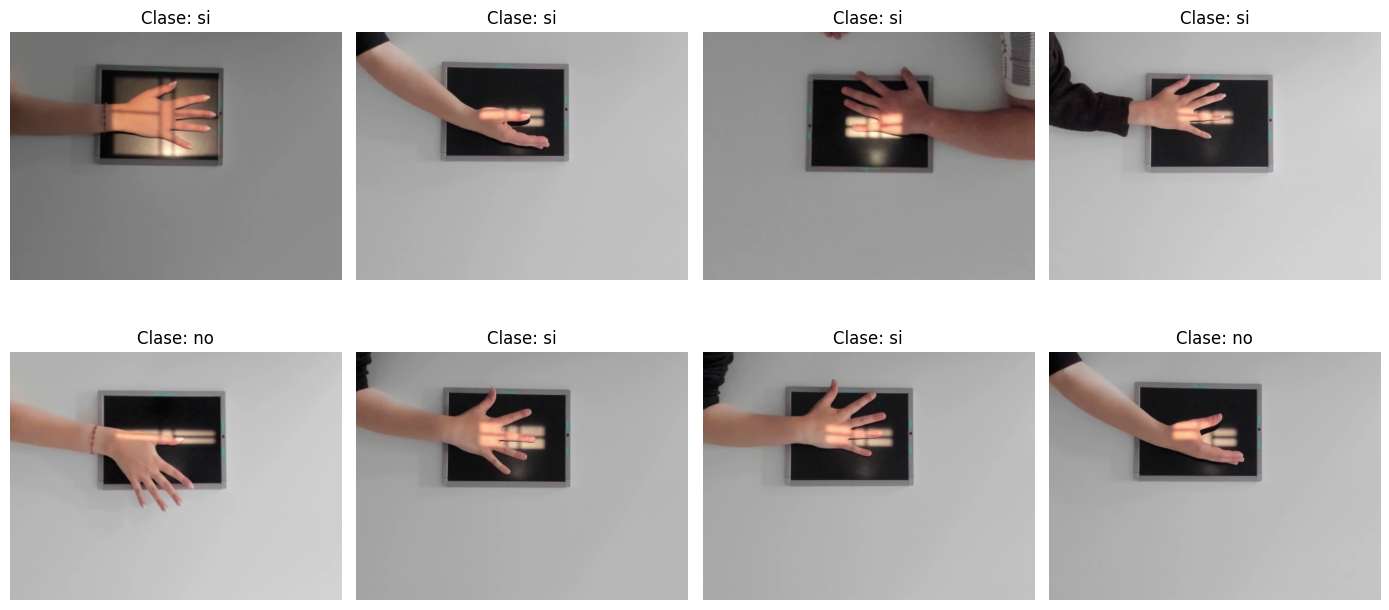

In [147]:
# Muestra aquí varias imágenes del dataset.
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

sample = train_df.sample(8, random_state=SEED).reset_index(drop=True)

for idx in range(8):
    img = PILImage.open(sample.loc[idx, 'path']).convert('RGB')
    axes[idx].imshow(img)
    axes[idx].axis('off')
    axes[idx].set_title(f"Clase: {sample.loc[idx, 'label']}")

plt.tight_layout()
plt.show()

## Preprocesado y transformaciones

Decidid qué transformaciones queréis usar.

Opciones posibles:

- `resize`;
- normalización;
- flips o rotaciones, si tienen sentido para la tarea;
- cambios de brillo o contraste;
- recorte del panel oscuro antes de pasar la imagen a la red.

Consejo: cada aumento debe ser plausible para el problema real.

In [148]:
# Define aquí las transformaciones de train y de evaluación.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Transformaciones de evaluación (sin augmentations)
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print('Transformaciones definidas correctamente.')

Transformaciones definidas correctamente.


## Dataset personalizado y dataloaders

Implementad aquí la parte que conecta el `DataFrame` con PyTorch.

Pensad qué debe devolver cada ejemplo:

- imagen transformada;
- etiqueta numérica;
- ruta o nombre de archivo si luego queréis analizar errores.

In [149]:
# Implementa aquí tu Dataset de PyTorch.
class DedoDataset(Dataset):
    """Dataset personalizado para la tarea 'dedo'."""

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = PILImage.open(row['path']).convert('RGB')
        label = int(row['label_idx'])
        path = row['path']

        if self.transform:
            img = self.transform(img)

        return img, label, path

# Verificar que funciona
sample_dataset = DedoDataset(train_df, transform=train_transform)
img, label, path = sample_dataset[0]
print(f'Imagen: {img.shape}, Etiqueta: {label} ({idx_to_label[label]}), Ruta: {path}')

Imagen: torch.Size([3, 224, 224]), Etiqueta: 1 (si), Ruta: /home/manel31/Escritorio/cursoIA/dedo/si/img_1777027756909.png


In [150]:
# Crea aquí los dataloaders de train, val y test.
train_dataset = DedoDataset(train_df, transform=train_transform)
val_dataset   = DedoDataset(val_df,   transform=eval_transform)
test_dataset  = DedoDataset(test_df,  transform=eval_transform)

# Crear dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Batches en train: {len(train_loader)}')
print(f'Batches en val:   {len(val_loader)}')
print(f'Batches en test:  {len(test_loader)}')

Batches en train: 2
Batches en val:   1
Batches en test:  1


## Inspeccionar un batch

Antes de entrenar, comprobad que las dimensiones y etiquetas tienen sentido.

Shape del batch de imágenes: torch.Size([32, 3, 224, 224])
Etiquetas en el batch: [1, 1, 1, 1, 0, 1, 0, 1]


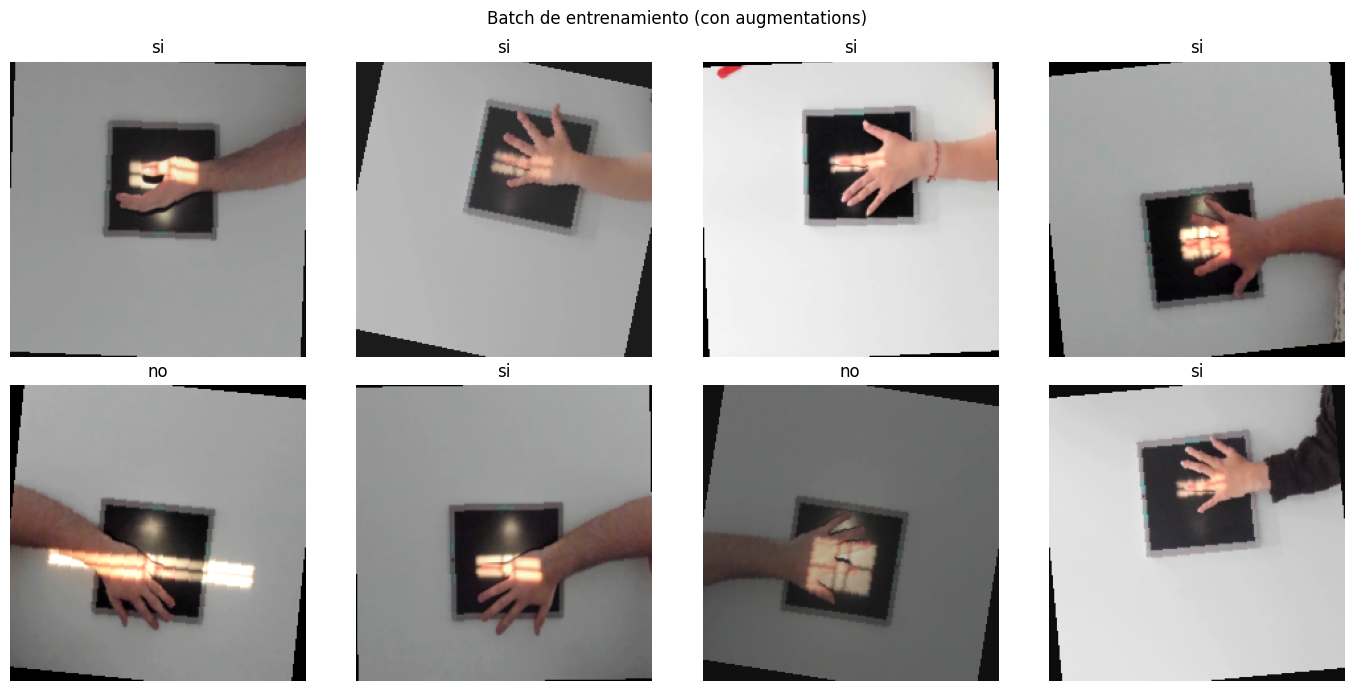

In [151]:
# Saca aquí un batch y visualiza varias imágenes transformadas.
imgs, labels, paths = next(iter(train_loader))

print(f'Shape del batch de imágenes: {imgs.shape}')
print(f'Etiquetas en el batch: {labels[:8].tolist()}')

# Función para desnormalizar para visualización
def denormalize(tensor):
    tensor = tensor.clone()
    mean = torch.tensor([0.5, 0.5, 0.5])
    std  = torch.tensor([0.5, 0.5, 0.5])
    tensor.mul_(std[:, None, None]).add_(mean[:, None, None])
    return tensor.clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()
for i in range(min(8, len(imgs))):
    img_show = denormalize(imgs[i]).permute(1, 2, 0).numpy()
    axes[i].imshow(img_show)
    axes[i].axis('off')
    axes[i].set_title(f'{idx_to_label[labels[i].item()]}')
plt.suptitle('Batch de entrenamiento (con augmentations)')
plt.tight_layout()
plt.show()

## Definir un primer modelo

Aquí podéis elegir vuestro punto de partida.

Posibilidades:

- una CNN pequeña y fácil de explicar;
- un modelo preentrenado con una cabeza final adaptada a dos clases.

In [152]:
# Define aquí un primer modelo.
n_classes = len(label_to_idx)
n_channels = 3

class SmallCNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2))

        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))

        self.layer3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))

        self.layer4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d(4))

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes))

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.fc(x)
        return x

# Instanciar el modelo
model = SmallCNN(in_channels=n_channels, num_classes=n_classes)
model = model.to(DEVICE)
print(model)

# Verificar con una entrada de prueba
sample_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
sample_output = model(sample_input)
print(f'\nSalida de prueba: {sample_output.shape}')

SmallCNN(
  (layer1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer4): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchN

## Entrenamiento

Montad un bucle de entrenamiento o usad una abstracción de más alto nivel si os resulta más cómodo.

Intentad registrar al menos:

- pérdida de entrenamiento;
- pérdida de validación;
- alguna métrica sencilla en validación.

In [153]:
# Entrena aquí el modelo.
# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

# Listas para guardar métricas
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    # Entrenamiento
    model.train()
    running_loss = 0.0
    for imgs, labels, _ in tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [train]'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)

    train_loss = running_loss / len(train_dataset)

    # Validar
    model.eval()
    val_loss = 0.0
    correct = 0
    with torch.no_grad():
        for imgs, labels, _ in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()

    val_loss /= len(val_dataset)
    val_acc = correct / len(val_dataset)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1:2d} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}')

# Guardar pesos del modelo
torch.save(model.state_dict(), 'weights_smallcnn_dedo.pth')
print('\nModelo guardado en weights_smallcnn_dedo.pth')

Epoch 1/60 [train]: 100%|██████████| 2/2 [00:00<00:00,  4.44it/s]


Epoch  1 | train_loss: 0.6659 | val_loss: 0.6950 | val_acc: 0.5000


Epoch 2/60 [train]: 100%|██████████| 2/2 [00:00<00:00,  4.48it/s]


Epoch  2 | train_loss: 0.8059 | val_loss: 0.6937 | val_acc: 0.5000


Epoch 3/60 [train]: 100%|██████████| 2/2 [00:00<00:00,  4.54it/s]


...

Epoch 58 | train_loss: 0.7227 | val_loss: 0.7654 | val_acc: 0.6250


Epoch 59/60 [train]: 100%|██████████| 2/2 [00:00<00:00,  4.55it/s]


Epoch 59 | train_loss: 0.7313 | val_loss: 0.7627 | val_acc: 0.6250


Epoch 60/60 [train]: 100%|██████████| 2/2 [00:00<00:00,  4.52it/s]


Epoch 60 | train_loss: 0.7119 | val_loss: 0.7623 | val_acc: 0.6250

Modelo guardado en weights_smallcnn_dedo.pth


## Curvas de aprendizaje

Representad la evolución del entrenamiento para ver si hay:

- aprendizaje real;
- sobreajuste;
- inestabilidad.

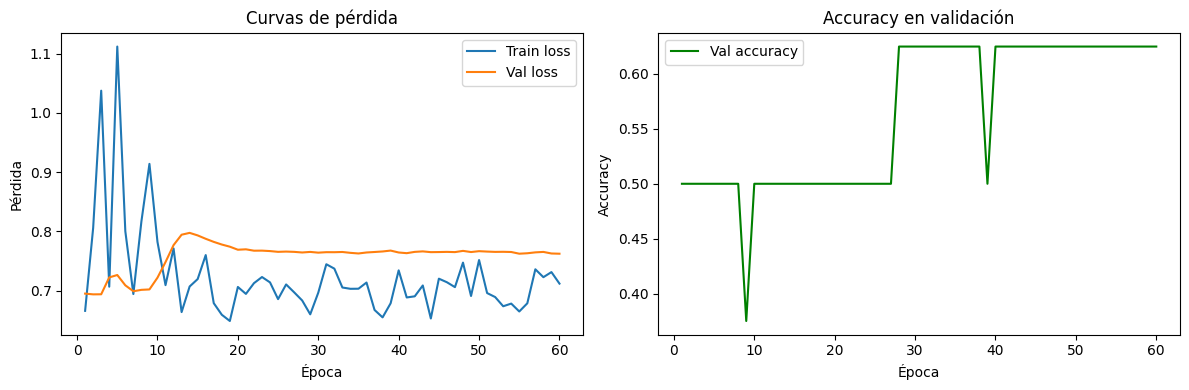

In [154]:
# Dibuja aquí las curvas de entrenamiento y validación.

epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pérdida
axes[0].plot(epochs, history['train_loss'], label='Train loss')
axes[0].plot(epochs, history['val_loss'],   label='Val loss')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Curvas de pérdida')
axes[0].legend()

# Accuracy
axes[1].plot(epochs, history['val_acc'], label='Val accuracy', color='green')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy en validación')
axes[1].legend()

plt.tight_layout()
plt.show()

## Predicción sobre test

Cuando tengáis un modelo elegido, aplicadlo al conjunto de test y guardad una tabla con al menos:

- ruta;
- etiqueta real;
- predicción;
- si es posible, una probabilidad o score.

In [155]:
# Genera aquí las predicciones sobre test.
model.eval()
all_paths, all_targets, all_preds, all_probs = [], [], [], []

with torch.no_grad():
    for imgs, labels, paths in tqdm(test_loader, desc='Predicción test'):
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        all_paths.extend(paths)
        all_targets.extend(labels.tolist())
        all_preds.extend(preds.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())

# Crear DataFrame de resultados
results_df = pd.DataFrame({
    'path':         all_paths,
    'label_real':   [idx_to_label[t] for t in all_targets],
    'label_pred':   [idx_to_label[p] for p in all_preds],
    'correct':      [t == p for t, p in zip(all_targets, all_preds)],
    'score_max':    [max(p) for p in all_probs]
})

print(results_df.head(10))
print(f'\nAccuracy en test: {results_df["correct"].mean():.4f}')

Predicción test: 100%|██████████| 1/1 [00:00<00:00,  9.82it/s]

                                                path label_real label_pred  \
0  /home/manel31/Escritorio/cursoIA/dedo/no/img_1...         no         si   
1  /home/manel31/Escritorio/cursoIA/dedo/no/img_1...         no         si   
2  /home/manel31/Escritorio/cursoIA/dedo/si/img_1...         si         si   
3  /home/manel31/Escritorio/cursoIA/dedo/si/img_1...         si         no   
4  /home/manel31/Escritorio/cursoIA/dedo/si/img_1...         si         si   
5  /home/manel31/Escritorio/cursoIA/dedo/si/img_1...         si         si   
6  /home/manel31/Escritorio/cursoIA/dedo/no/img_1...         no         si   
7  /home/manel31/Escritorio/cursoIA/dedo/si/img_1...         si         si   
8  /home/manel31/Escritorio/cursoIA/dedo/no/img_1...         no         si   
9  /home/manel31/Escritorio/cursoIA/dedo/si/img_1...         si         no   

   correct  score_max  
0    False   0.540725  
1    False   0.549915  
2     True   0.521931  
3    False   0.502218  
4     True   0.551390

## Evaluación

Calculad al menos:

- accuracy;
- precision;
- recall;
- F1;
- matriz de confusión.

In [156]:
# Calcula aquí las métricas.
y_true = all_targets
y_pred = all_preds

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1 score:  {f1:.4f}')
print()
print('Informe de clasificación:')
print(classification_report(
    y_true, y_pred,
    target_names=[idx_to_label[i] for i in range(n_classes)],
    zero_division=0
))

Accuracy:  0.4118
Precision: 0.2471
Recall:    0.4118
F1 score:  0.3088

Informe de clasificación:
              precision    recall  f1-score   support

          no       0.00      0.00      0.00         8
          si       0.47      0.78      0.58         9

    accuracy                           0.41        17
   macro avg       0.23      0.39      0.29        17
weighted avg       0.25      0.41      0.31        17



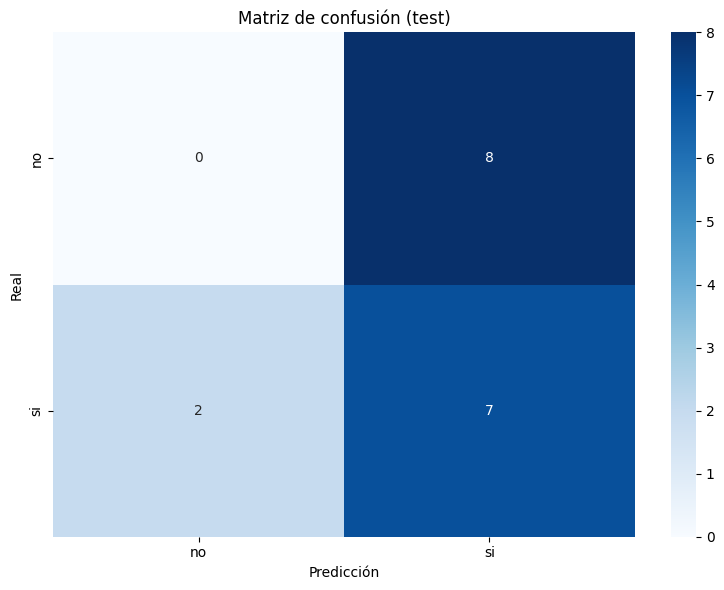

In [157]:
# Dibuja aquí la matriz de confusión.

cm = confusion_matrix(y_true, y_pred)
class_names = [idx_to_label[i] for i in range(n_classes)]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión (test)')
plt.tight_layout()
plt.show()

## Analizar aciertos y errores

Mostrad ejemplos bien y mal clasificados.

Aciertos: 7 | Errores: 10


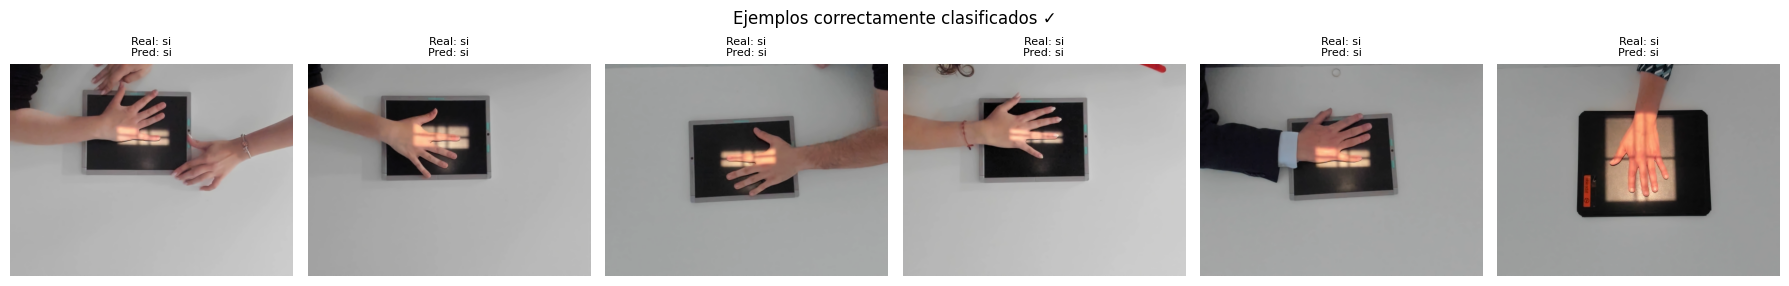

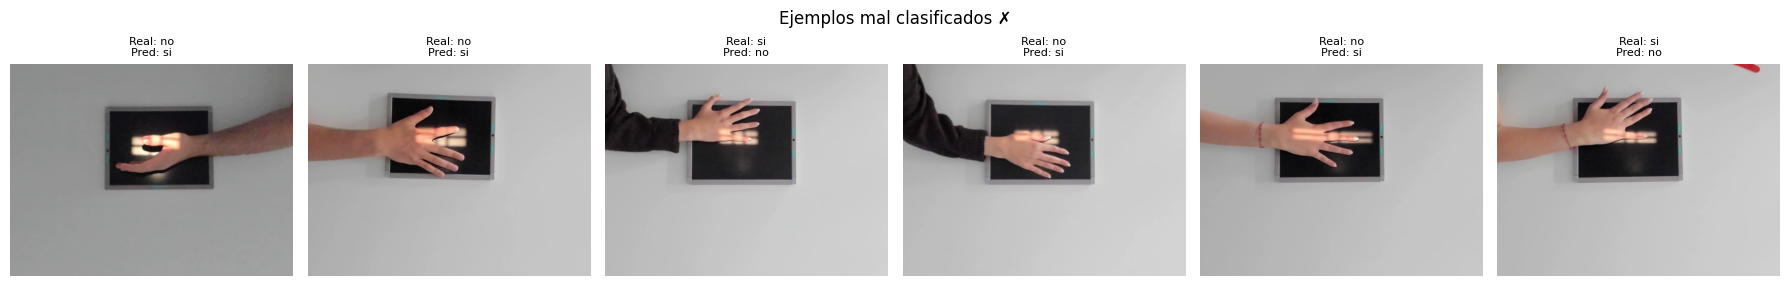

In [158]:
# Visualiza aquí ejemplos de aciertos y errores.
correct_df = results_df[results_df['correct']].reset_index(drop=True)
error_df   = results_df[~results_df['correct']].reset_index(drop=True)

def show_examples(subset_df, title, n=6):
    sample = subset_df.sample(min(n, len(subset_df)), random_state=SEED).reset_index(drop=True)
    fig, axes = plt.subplots(1, len(sample), figsize=(3 * len(sample), 3))
    if len(sample) == 1:
        axes = [axes]
    for i, row in sample.iterrows():
        img = PILImage.open(row['path']).convert('RGB')
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f"Real: {row['label_real']}\nPred: {row['label_pred']}", fontsize=8)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

print(f'Aciertos: {len(correct_df)} | Errores: {len(error_df)}')
show_examples(correct_df, 'Ejemplos correctamente clasificados ✓')
show_examples(error_df,   'Ejemplos mal clasificados ✗')

## Comparación opcional entre enfoques

Si os da tiempo, comparad dos variantes distintas. Algunas ideas:

- CNN pequeña frente a modelo preentrenado;
- imagen completa frente a panel recortado;
- aumentos suaves frente a aumentos más fuertes.

MobileNet Epoch 1/5: 100%|██████████| 2/2 [00:00<00:00,  4.63it/s]


MobileNet Epoch 1 | val_loss: 0.7550 | val_acc: 0.2500


MobileNet Epoch 2/5: 100%|██████████| 2/2 [00:00<00:00,  4.77it/s]


MobileNet Epoch 2 | val_loss: 0.7978 | val_acc: 0.5000


MobileNet Epoch 3/5: 100%|██████████| 2/2 [00:00<00:00,  4.85it/s]


MobileNet Epoch 3 | val_loss: 0.7960 | val_acc: 0.5000


MobileNet Epoch 4/5: 100%|██████████| 2/2 [00:00<00:00,  4.90it/s]


MobileNet Epoch 4 | val_loss: 0.7841 | val_acc: 0.5000


MobileNet Epoch 5/5: 100%|██████████| 2/2 [00:00<00:00,  4.89it/s]


MobileNet Epoch 5 | val_loss: 0.7976 | val_acc: 0.5000


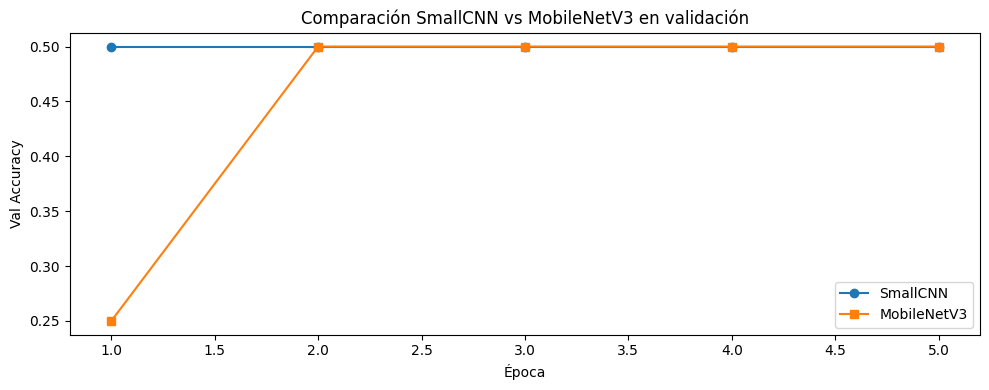

In [159]:
# Compara aquí dos enfoques distintos si llegas a ello.
mobilenet = mobilenet_v3_small(weights='IMAGENET1K_V1')
num_ftrs = mobilenet.classifier[-1].in_features
mobilenet.classifier[-1] = nn.Linear(num_ftrs, n_classes)
mobilenet = mobilenet.to(DEVICE)

optimizer_mn = optim.Adam(mobilenet.parameters(), lr=LEARNING_RATE)
history_mn = {'train_loss': [], 'val_loss': [], 'val_acc': []}

EPOCHS_COMPARISON = min(5, NUM_EPOCHS)

for epoch in range(EPOCHS_COMPARISON):
    mobilenet.train()
    running_loss = 0.0
    for imgs, labels, _ in tqdm(train_loader, desc=f'MobileNet Epoch {epoch+1}/{EPOCHS_COMPARISON}'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer_mn.zero_grad()
        loss = criterion(mobilenet(imgs), labels)
        loss.backward()
        optimizer_mn.step()
        running_loss += loss.item() * imgs.size(0)

    train_loss = running_loss / len(train_dataset)

    mobilenet.eval()
    val_loss, correct = 0.0, 0
    with torch.no_grad():
        for imgs, labels, _ in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = mobilenet(imgs)
            val_loss += criterion(out, labels).item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()

    val_loss /= len(val_dataset)
    val_acc = correct / len(val_dataset)
    history_mn['train_loss'].append(train_loss)
    history_mn['val_loss'].append(val_loss)
    history_mn['val_acc'].append(val_acc)
    print(f'MobileNet Epoch {epoch+1} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}')

# Comparación de curvas de validación
epochs_comp = range(1, EPOCHS_COMPARISON + 1)
plt.figure(figsize=(10, 4))
plt.plot(epochs_comp, history['val_acc'][:EPOCHS_COMPARISON],    label='SmallCNN', marker='o')
plt.plot(epochs_comp, history_mn['val_acc'],                     label='MobileNetV3', marker='s')
plt.xlabel('Época')
plt.ylabel('Val Accuracy')
plt.title('Comparación SmallCNN vs MobileNetV3 en validación')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusiones

Escribid aquí unas conclusiones breves:

- qué arquitectura habéis usado;
- qué decisiones de datos os han ayudado más;
- qué problemas habéis encontrado;